This notebook is modified from the example/channel_response.ipynb of the original repo: https://github.com/ant-uni-bremen/OpenNTN/

In [11]:
import os
from sionna.phy.channel import GenerateOFDMChannel
gpu_num = 0 # Use "" to use the CPU
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Import Sionna
import sionna

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import matplotlib.pyplot as plt
import numpy as np

from sionna.phy.ofdm import ResourceGrid
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel

# These functions also exist in sionna.channel.tr38901 but are not compatable with 3GPP TR38.811
from sionna.phy.channel.tr38901 import Antenna, AntennaArray

In [12]:
# Import the NTN channel models from the local OpenNTN package
import sys
sys.path.append('../')  # Add parent directory to path to access OpenNTN
from OpenNTN import DenseUrban, Urban, SubUrban
from OpenNTN.utils import gen_single_sector_topology as gen_ntn_topology

In [13]:
scenario = "dur" # dur, sur, urb
carrier_frequency = 27e9 # DL S-Band
direction = "downlink"
elevation_angle = 50.0
num_ut = 1
satellite_height = 600000.0 # Height in meters, this is a satellite in the Low Earth Orbit (LEO)
batch_size = 32 # Number of topologies we will generate later  

In [14]:
ut_array = Antenna(polarization="single",
                    polarization_type="V",
                    antenna_pattern="omni",
                    carrier_frequency=carrier_frequency)

# The satellite is the basestation, so we name it bs. 
bs_array = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="dual",
                        polarization_type="VH",
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)
N_samples = 2048


In [15]:
num_streams_per_tx = 1 
num_time_steps = 14
RBBlock = 11
nFFT = int(2** (np.ceil(np.log2(RBBlock * 12)))) 
SCS = 60e3
sampling_frequency = SCS * nFFT # set equal to waveformInfo.SampleRate in MATLAB
        # maybe different because in MATLAB, number of subcariers is different to the Nfft

rg = ResourceGrid(num_ofdm_symbols=14,
                    fft_size=nFFT, # 
                    subcarrier_spacing=SCS,
                    num_tx=num_ut,
                    num_streams_per_tx=num_streams_per_tx,
                    cyclic_prefix_length=26,
                    num_guard_carriers=(62, 62),     # 256 - 132 = 124 zeroed carriers
                    dc_null=False, 
                    pilot_pattern="kronecker",
                    pilot_ofdm_symbol_indices=[2,11])

# Function that calculates the subcarrier frequencies of the OFDM frame
frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)

In [16]:
from OpenNTN.utils import compute_stallite_doppler as compute_stallite_doppler 

In [17]:
aa = compute_stallite_doppler(satellite_height, elevation_angle, carrier_frequency)
aa

<tf.Tensor: shape=(), dtype=float32, numpy=27000400000.0>

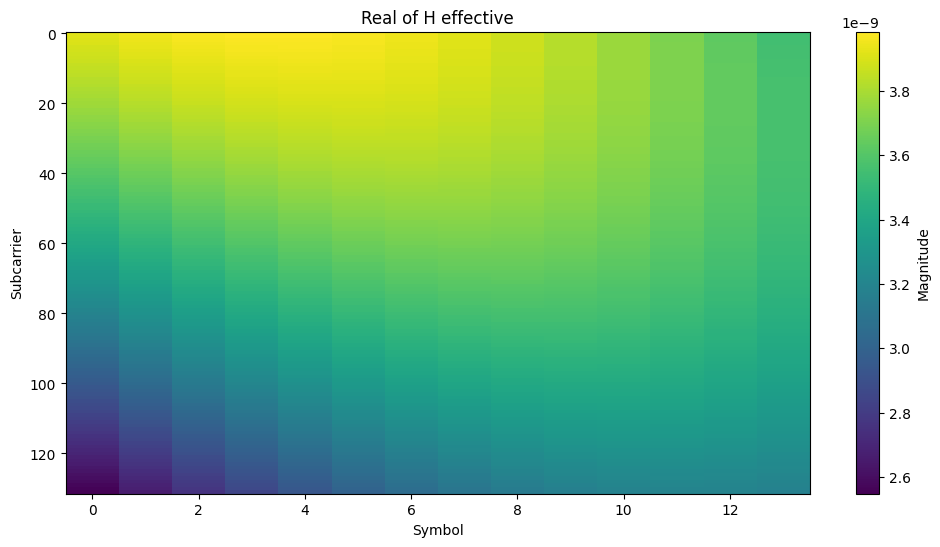

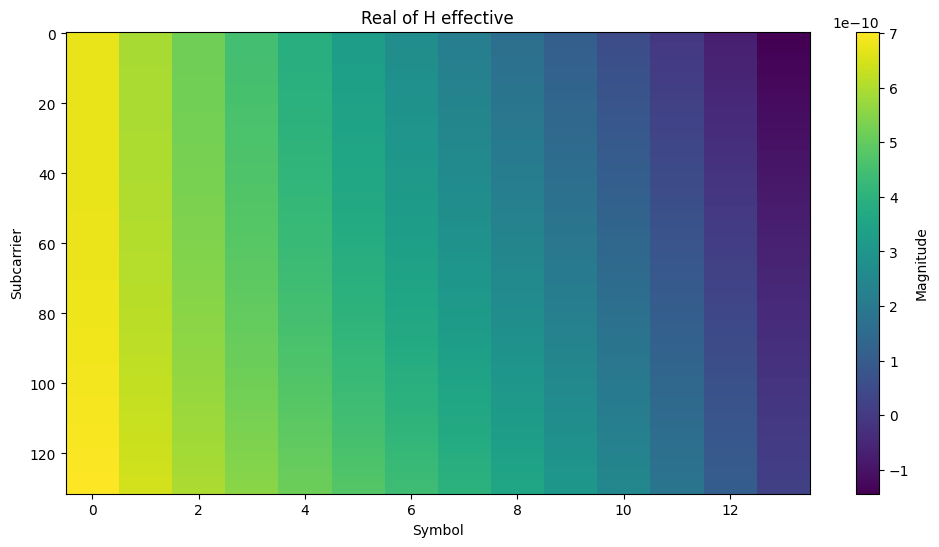

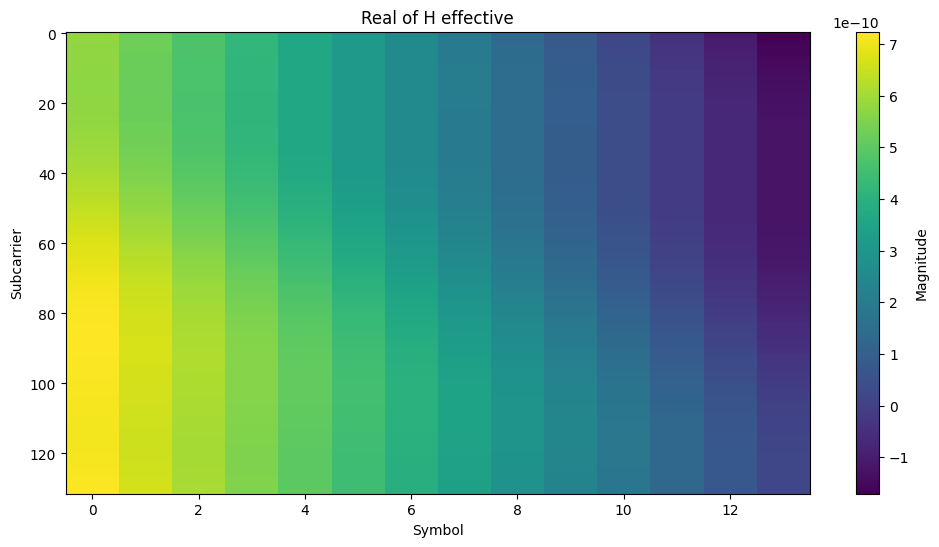

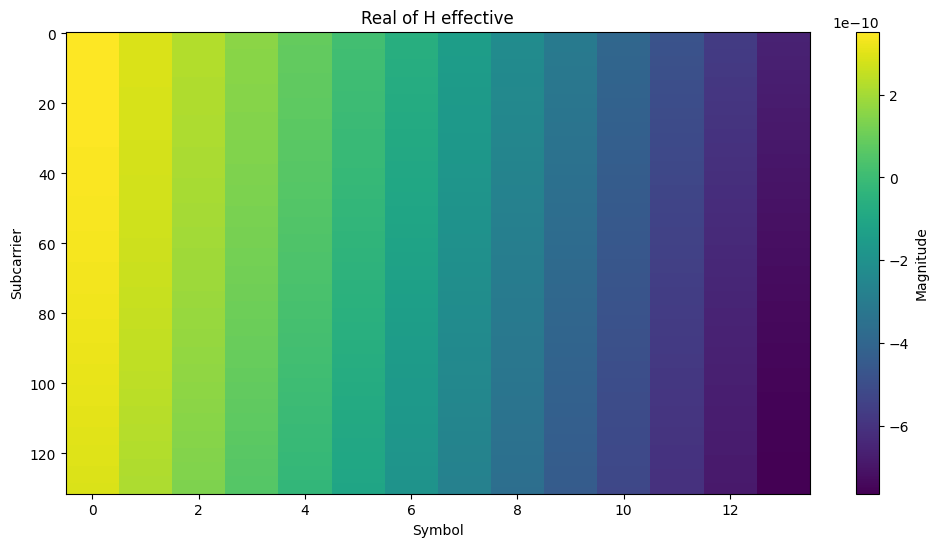

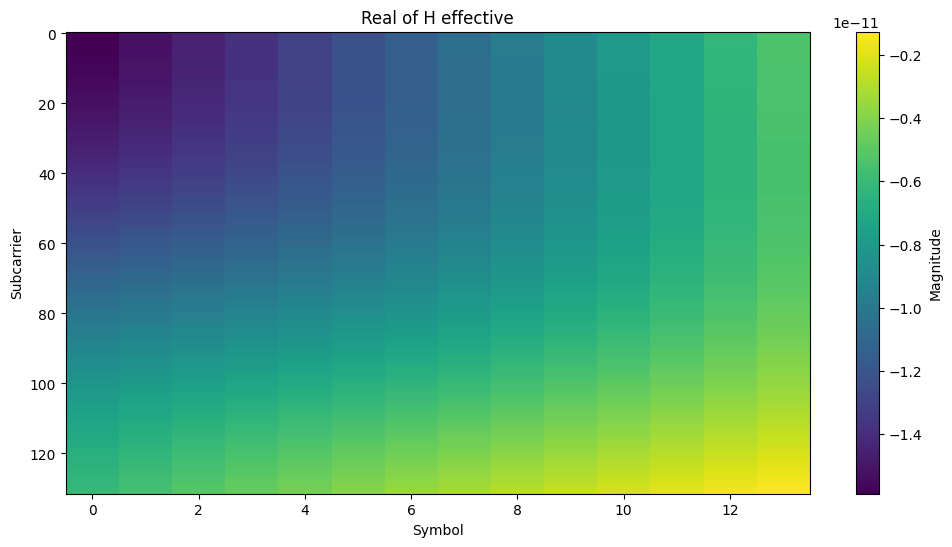

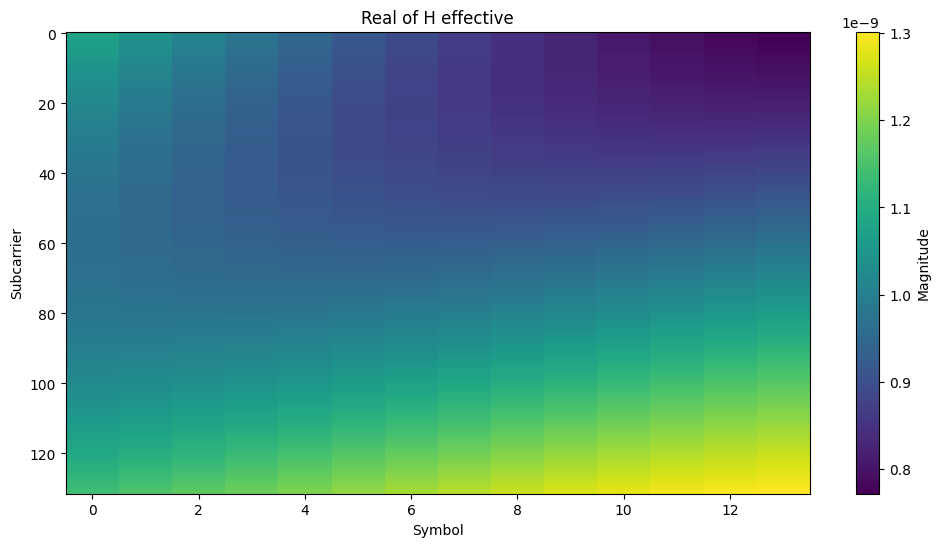

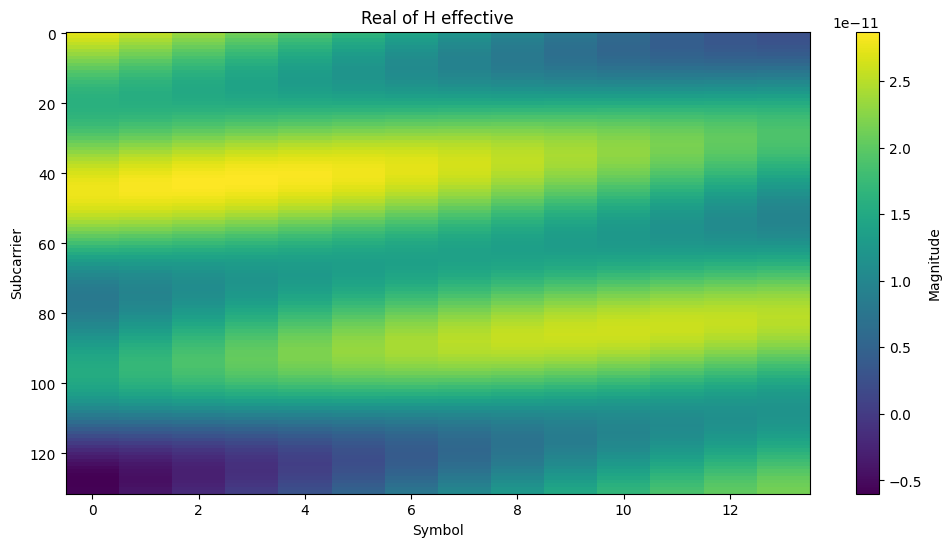

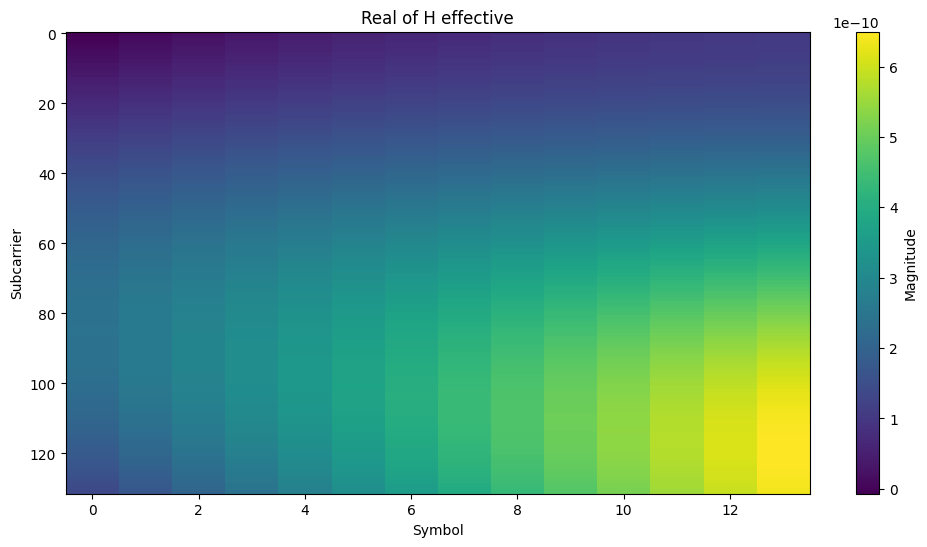

In [29]:
from OpenNTN.utils import cir_to_time_channel, time_lag_discrete_time_channel
from sionna.phy.ofdm import RemoveNulledSubcarriers
bandwidth = rg.fft_size * rg.subcarrier_spacing

# Set a constant UE speed of 30 m/s (approx. 108 km/h)
ue_speed = 20.0 

H_perfect = [] # to be in size of [14,132,N]
H_efficient = []
for i in range(2): # (N_samples//(batch_size *2)):
    # Here we match choose DenseUrban to match the parameter "dur" for the scenario defined above
    channel_model = DenseUrban(carrier_frequency=carrier_frequency,
                            ut_array=ut_array,
                            bs_array=bs_array,
                            direction=direction,
                            elevation_angle=elevation_angle,
                            doppler_enabled=False)

    channel_model._scenario._params_nlos["numClusters_50"] = 3

    # Generate the topology
    topology = gen_ntn_topology(batch_size=batch_size,
                            num_ut=num_ut, scenario=scenario,
                            bs_height=satellite_height,
                            min_ut_velocity=ue_speed,
                            max_ut_velocity=ue_speed)
    # topology = gen_ntn_topology(batch_size=batch_size, num_ut=num_ut, min_ut_height=ue_height, max_ut_height=ue_height, scenario=scenario,bs_height=satellite_height)

    # Set the topology
    channel_model.set_topology(*topology)

    # path_coefficients [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    # path_delays [batch size, num_rx, num_tx, num_paths]
    num_time_steps = 14 * (rg.fft_size + rg.cyclic_prefix_length)
    # symbol_start = np.arange(1, 14) * 132
    # # symbol_start = np.concatenate(([22], np.arange(1, 14) * (132 + 18))) # 256       % including CP
    # symbol_start = tf.constant(symbol_start, dtype=tf.int32)
    path_coefficients, path_delays = channel_model(num_time_steps, sampling_frequency)
    # h = cir_to_ofdm_channel(frequencies, path_coefficients, path_delays)
    # Convert CIR -> discrete time-domain channel taps h_t[b, l]
    l_min, l_max = time_lag_discrete_time_channel(bandwidth)
    h_t = cir_to_time_channel(
        bandwidth=bandwidth,
        a=path_coefficients,
        tau=path_delays,
        l_min=l_min,
        l_max=l_max,
        normalize=False
    )
    
    ofdm_channel = GenerateOFDMChannel(channel_model, resource_grid=rg)
    h_freq= ofdm_channel()
    
    remove_nulled = RemoveNulledSubcarriers(rg)
    h_perfect_ori = remove_nulled(h_freq)   # -> [..., 14, 132]
    
    h_freq_plot = (h_perfect_ori[1,0,0,0,0,:,:]).numpy().real
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Real of H effective')
    plt.show()

    h_freq_plot = (h_perfect_ori[2,0,0,0,0,:,:]).numpy().real
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Real of H effective')
    plt.show()

    h_freq_plot = (h_perfect_ori[3,0,0,0,0,:,:]).numpy().real
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Real of H effective')
    plt.show()

    h_freq_plot = (h_perfect_ori[4,0,0,0,0,:,:]).numpy().real
    h_freq_plot = h_freq_plot.T

    # Plot the concatenated heatmap
    plt.figure(figsize=(12, 6))
    plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Symbol')
    plt.ylabel('Subcarrier')
    plt.title('Real of H effective')
    plt.show()

    # Check LoS status for all 32 topology drops in the batch
    channel_model._scenario.los.numpy().squeeze()
    
    

In [27]:
channel_model._scenario._params_nlos["numClusters_50"]

<tf.Tensor: shape=(), dtype=int32, numpy=4>

In [19]:
channel_model._scenario.los.numpy().squeeze()

array([False,  True,  True,  True, False, False,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True, False,  True, False, False,
       False, False, False,  True,  True])

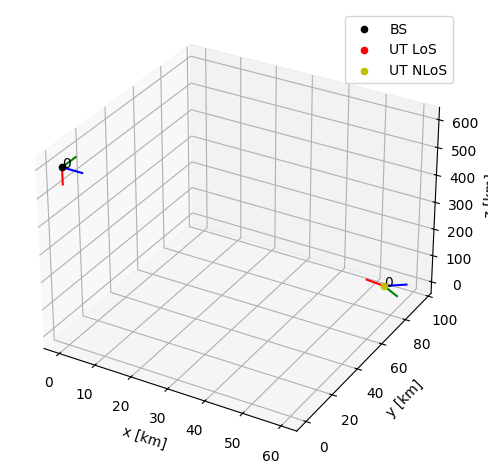

In [23]:
channel_model.show_topology()

In [21]:
(h_perfect_ori[1,:,:,0,0,0,0]).numpy().real

array([[1.5335248e-09]], dtype=float32)

In [22]:
H_eff.shape

NameError: name 'H_eff' is not defined

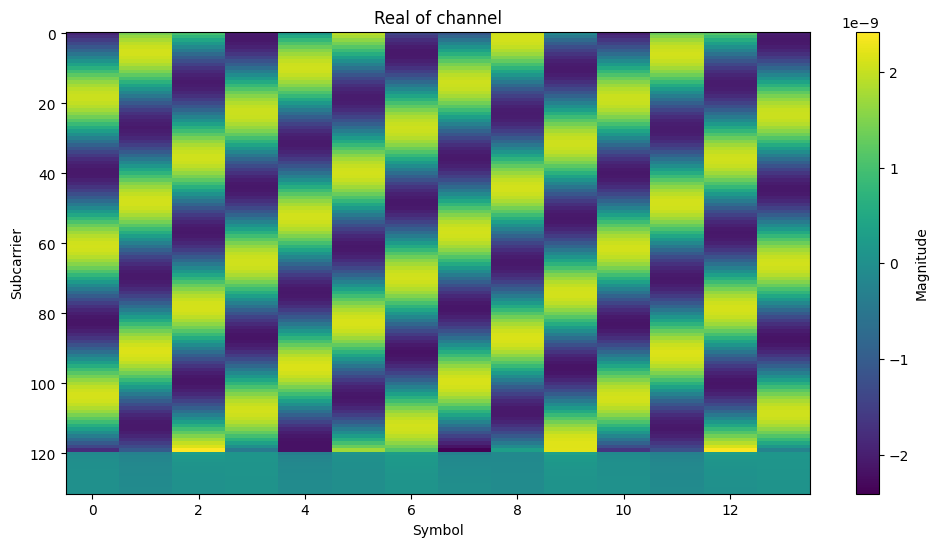

In [ ]:
H_eff.shape
h_freq_plot = (H_eff[1,:,:]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

In [ ]:
H_perfect = tf.concat(H_perfect, axis=-1) # H to save: [14, 132, N]
H_perfect.shape

TensorShape([14, 256, 128])

In [ ]:
import scipy.io

H_perfect_numpy = H_perfect.numpy()
scipy.io.savemat('H_perfect_withoutDoppCom.mat', {'H_perfect': H_perfect_numpy})

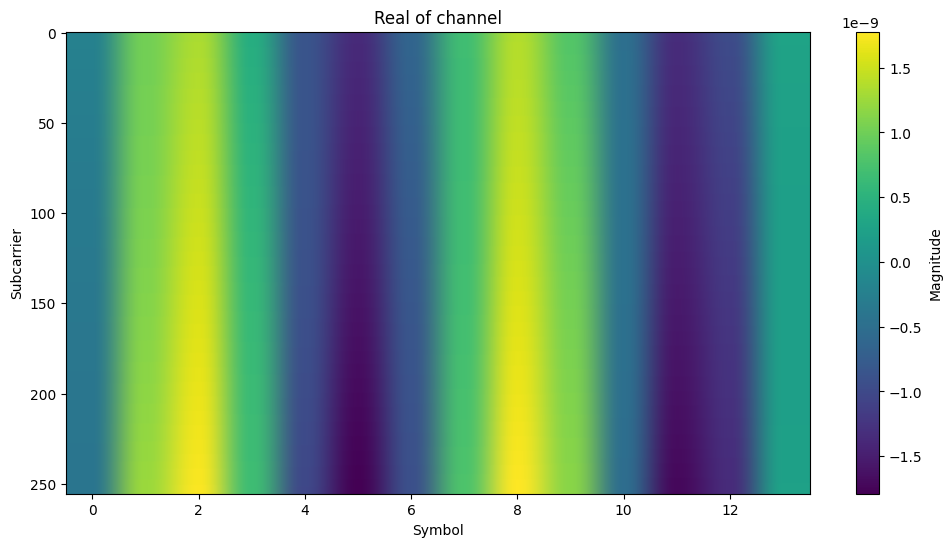

In [ ]:
h_freq_plot = (H_perfect[:,:,2]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

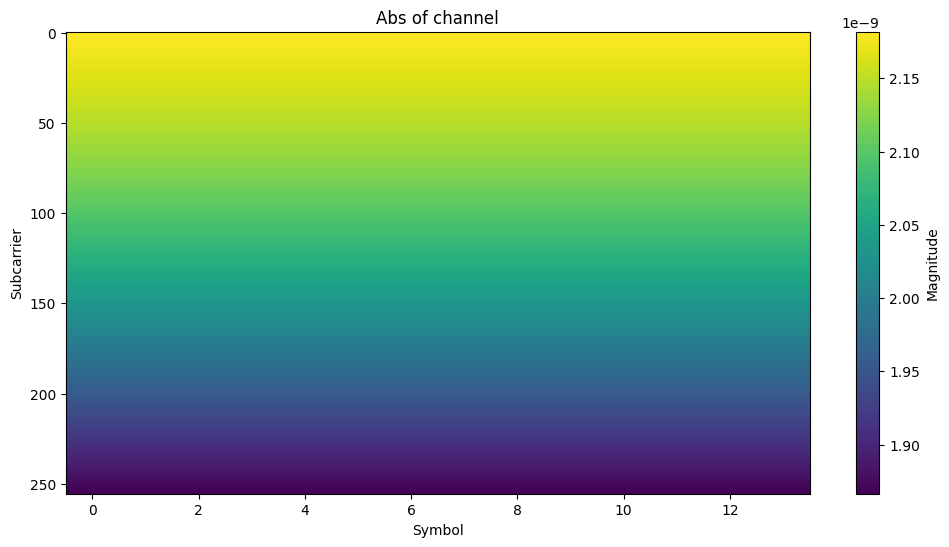

In [ ]:
# h_freq_plot = (H_perfect[:,:,1]).numpy().real
h_freq_plot = tf.abs(H_perfect[:,:,11]).numpy()
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Abs of channel')
plt.show()

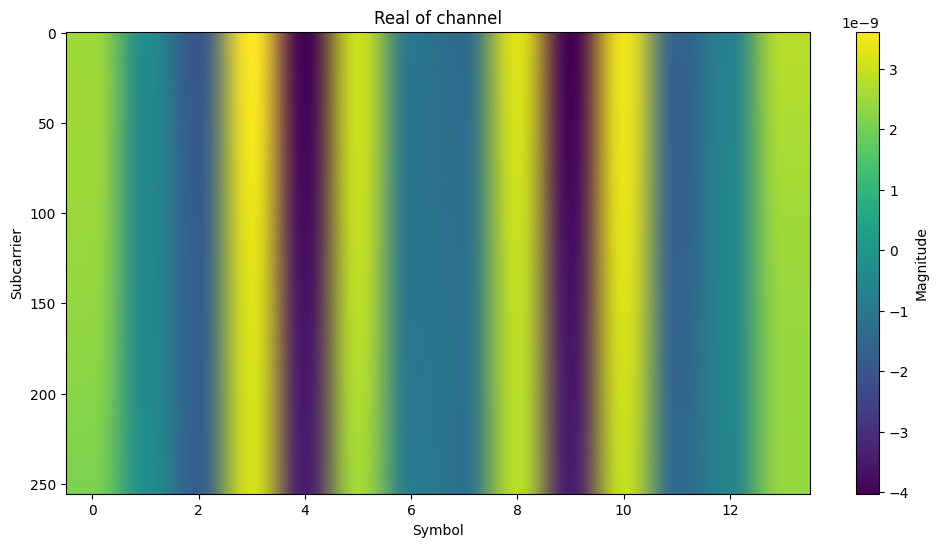

In [ ]:
h_freq_plot = (H_perfect[:,:,3]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

In [ ]:
h_freq_plot = (h[2,  0,0,  0,0,  :,:]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:CPU:0}} Index out of range using input dim 3; input has only 3 dims [Op:StridedSlice] name: strided_slice/

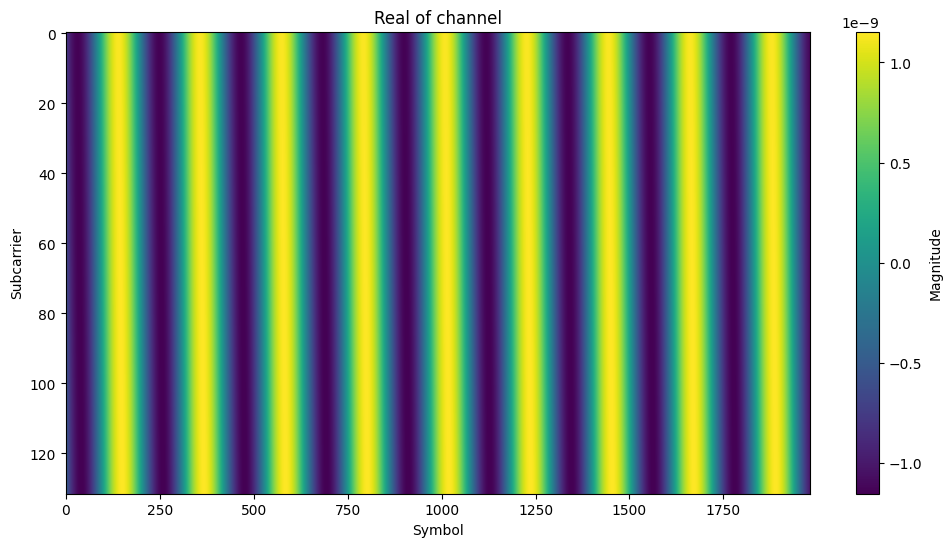

In [ ]:
h_freq_plot = (h[19,  0,0,  0,1,  :,:]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

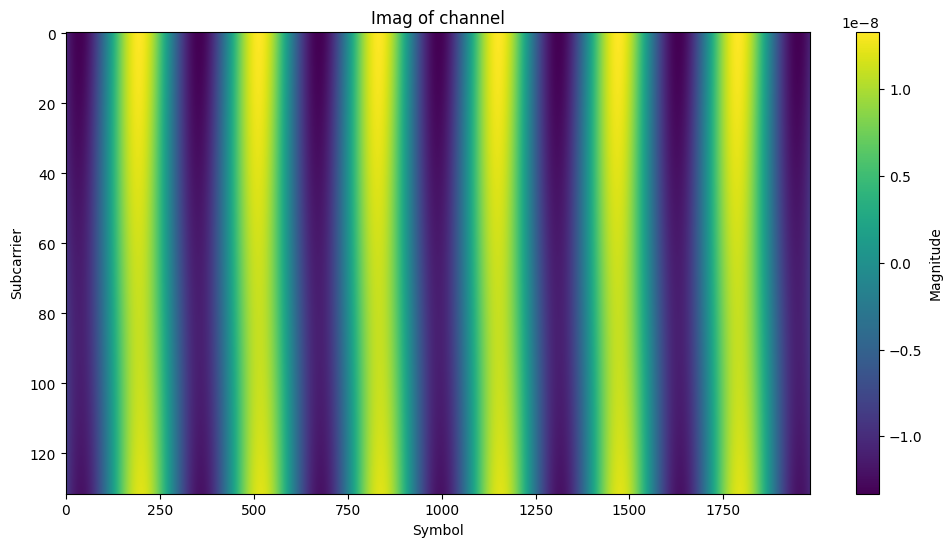

In [ ]:
h_freq_plot = (h[0,0,0,0,0,:,:]).numpy().imag
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Imag of channel')
plt.show()

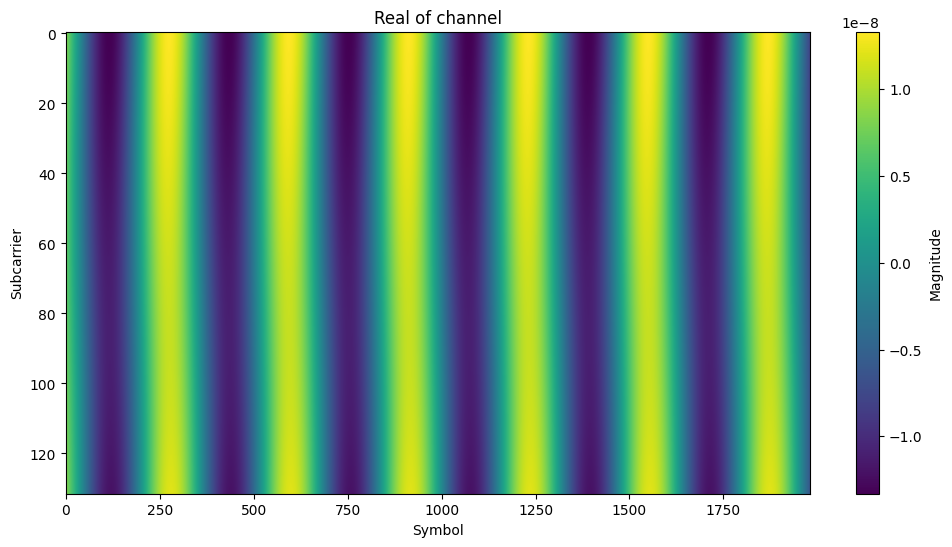

In [ ]:
h_freq_plot = (h[0,0,0,0,0,:,:]).numpy().real
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Real of channel')
plt.show()

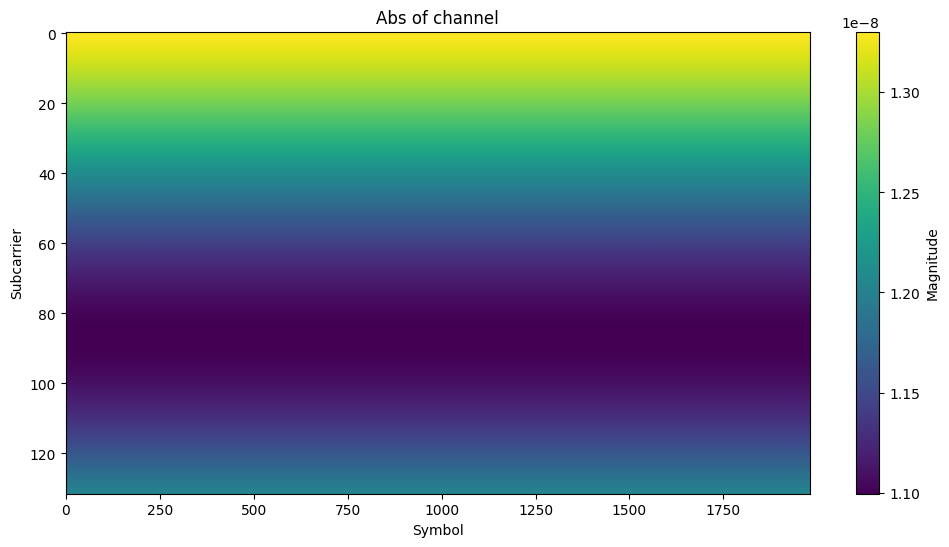

In [ ]:
h_freq_plot = tf.abs(h[0,0,0,0,0,:,:]).numpy() 
h_freq_plot = h_freq_plot.T

# Plot the concatenated heatmap
plt.figure(figsize=(12, 6))
plt.imshow(h_freq_plot, aspect='auto', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.xlabel('Symbol')
plt.ylabel('Subcarrier')
plt.title('Abs of channel')
plt.show()